# Lecture 05 (B04): Architecture search and loss balancing

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §Chapter 4 (Neural architecture search and loss normalization)  
**Notebook role:** exercise  
**Original live-course source:** `lectures/day3/code/05_IRBC_Exercise.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Exercise: IRBC Model — Comparative Statics and Loss Weighting

*Companion notebook to **Day 3 — IRBC, NAS, Loss Normalization** (Chapters 3–4 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

In this exercise you will work with the **2-country International Real Business Cycle (IRBC)** model
from **`01_IRBC_DEQN.ipynb`**. Rather than re-training the full model, you will:

1. **Task 1 (10 min):** Perform comparative statics on the deterministic steady state — change one
   parameter at a time ($\beta$, $\delta$, $\zeta$) and observe how steady-state capital and consumption respond.
2. **Task 2 (10 min):** Implement **inverse-loss weighting** for a multi-component loss function
   (Euler equations, resource constraint, Fischer-Burmeister complementarity).
3. **Task 3 (10 min):** Compare synthetic training histories from equal-weight vs. inverse-weight
   approaches and quantify the convergence speedup.

**Reference:** The full model and training pipeline are in `01_IRBC_DEQN.ipynb` (same directory).
Loss normalization theory is covered in `03_Loss_Normalization.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13

## Task 1: Comparative Statics (10 min)

The 2-country IRBC model has the following key parameters:

| Parameter | Symbol | Baseline Value | Meaning |
|-----------|--------|---------------|---------|
| Discount factor | $\beta$ | 0.99 | Household patience |
| Depreciation | $\delta$ | 0.025 | Capital decay rate |
| Capital share | $\zeta$ | 0.36 | Output elasticity of capital |
| Adjustment cost | $\kappa$ | 0.5 | Investment friction |

At the **deterministic steady state** (no shocks, $z^j = 0$), the Euler equation implies $\text{MPK} = 1/\beta$, giving:

$$k_{ss} = \left(\frac{1/\beta - 1 + \delta}{\zeta \cdot A_{\text{tfp}}}\right)^{1/(\zeta - 1)}, \qquad c_{ss} = A_{\text{tfp}} \cdot k_{ss}^\zeta - \delta \cdot k_{ss}$$

where $A_{\text{tfp}}$ is set so that the model is well-calibrated.

For this exercise we deliberately use a **standalone calibration with $A_{\text{tfp}} = 1$**: it makes the comparative-statics numbers easier to read at a glance and decouples the exercise from the IRBC training notebook.  The reference notebook `01_IRBC_DEQN.ipynb` instead pins $A_{\text{tfp}} = (1 - \beta(1-\delta))/(\zeta\beta) \approx 0.0559$ so that $k_{ss} = 1$ (a normalisation convention used throughout Chapter 3).  Changing the calibration only rescales $k_{ss}$ and $c_{ss}$ without changing the qualitative comparative-statics conclusions of this task.

**Goal:** Understand how each parameter shifts steady-state capital and consumption.

In [2]:
def compute_steady_state(beta, delta, zeta, A_tfp=1.0):
    """Compute steady-state capital and consumption for the IRBC model."""
    k_ss = ((1.0 / beta - 1.0 + delta) / (zeta * A_tfp)) ** (1.0 / (zeta - 1.0))
    c_ss = A_tfp * k_ss ** zeta - delta * k_ss
    return k_ss, c_ss

# --- Baseline calibration ---
beta_base, delta_base, zeta_base = 0.99, 0.025, 0.36
k_base, c_base = compute_steady_state(beta_base, delta_base, zeta_base)
print(f"Baseline (beta={beta_base}, delta={delta_base}, zeta={zeta_base}):")
print(f"  k_ss = {k_base:.4f},  c_ss = {c_base:.4f}")

# --- Effect of higher depreciation ---
delta_high = 0.05
k_high_d, c_high_d = compute_steady_state(beta_base, delta_high, zeta_base)
print(f"\nHigher depreciation (delta={delta_high}):")
print(f"  k_ss = {k_high_d:.4f},  c_ss = {c_high_d:.4f}")
print(f"  Change in k_ss: {(k_high_d / k_base - 1) * 100:.1f}%")
print(f"  Change in c_ss: {(c_high_d / c_base - 1) * 100:.1f}%")

Baseline (beta=0.99, delta=0.025, zeta=0.36):
  k_ss = 37.9893,  c_ss = 2.7543

Higher depreciation (delta=0.05):
  k_ss = 16.3953,  c_ss = 1.9174
  Change in k_ss: -56.8%
  Change in c_ss: -30.4%


### Your Turn: Parameter Sensitivity

Using the `compute_steady_state()` function above, compute $k_{ss}$ and $c_{ss}$ for:

**(a)** Lower discount factor: $\beta = 0.95$ (more impatient households) vs. baseline $\beta = 0.99$.

**(b)** Lower capital share: $\zeta = 0.30$ (less capital-intensive production) vs. baseline $\zeta = 0.36$.

**Before computing**, write down your prediction: does $k_{ss}$ go up or down? Why?

In [3]:
# =====================================================================
# TODO: Compute steady-state capital and consumption for beta = 0.95
# =====================================================================
beta_low = 0.95
# k_ss_low, c_ss_low = ...


# =====================================================================
# TODO: Compute steady-state capital and consumption for zeta = 0.30
# =====================================================================
zeta_low = 0.30
# k_ss_zeta, c_ss_zeta = ...


# =====================================================================
# TODO: Print a comparison table with all four scenarios
# (baseline, high delta, low beta, low zeta)
# =====================================================================


<hr style="border-top: 2px dashed #c0392b;">

### Stop --- attempt Task 1 above before continuing

The reference solution to **the steady-state comparative statics** appears in the next code cell.
Spend ~5 minutes wrestling with the blank version first --- you'll
remember the mechanics far better than if you read the answer cold.

<br>
<br>
<br>

<hr style="border-top: 2px dashed #c0392b;">

### Solution

Scenario               beta  delta   zeta     k_ss     c_ss     dk%     dc%
---------------------------------------------------------------------------
Baseline              0.990  0.025   0.36  37.9893   2.7543    +0.0    +0.0
High delta=0.05       0.990  0.050   0.36  16.3953   1.9174   -56.8   -30.4
Low beta=0.95         0.950  0.025   0.36  10.9910   2.0954   -71.1   -23.9
Low zeta=0.30         0.990  0.025   0.30  21.4361   1.9722   -43.6   -28.4


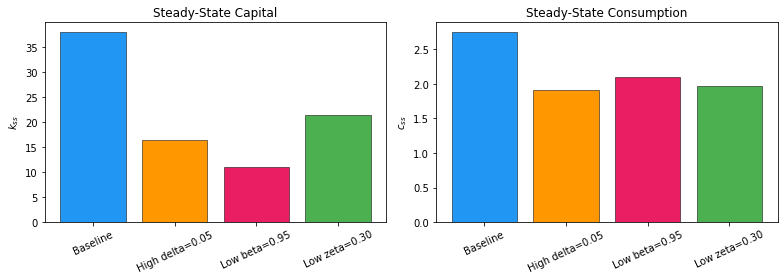


Economic intuition:
  - Lower beta => higher required return => lower k_ss (impatient households save less)
  - Lower zeta => diminishing returns kick in earlier => lower k_ss
  - Higher delta => more replacement investment needed => lower k_ss


In [4]:
# (a) Lower discount factor
beta_low = 0.95
k_ss_low, c_ss_low = compute_steady_state(beta_low, delta_base, zeta_base)

# (b) Lower capital share
zeta_low = 0.30
k_ss_zeta, c_ss_zeta = compute_steady_state(beta_base, delta_base, zeta_low)

# --- Comparison table ---
scenarios = [
    ("Baseline",           beta_base, delta_base, zeta_base, k_base,    c_base),
    ("High delta=0.05",    beta_base, delta_high,  zeta_base, k_high_d,  c_high_d),
    ("Low beta=0.95",      beta_low,  delta_base, zeta_base, k_ss_low,  c_ss_low),
    ("Low zeta=0.30",      beta_base, delta_base, zeta_low,  k_ss_zeta, c_ss_zeta),
]

print(f"{'Scenario':<20s} {'beta':>6s} {'delta':>6s} {'zeta':>6s} {'k_ss':>8s} {'c_ss':>8s} {'dk%':>7s} {'dc%':>7s}")
print("-" * 75)
for name, b, d, z, k, c in scenarios:
    dk = (k / k_base - 1) * 100
    dc = (c / c_base - 1) * 100
    print(f"{name:<20s} {b:6.3f} {d:6.3f} {z:6.2f} {k:8.4f} {c:8.4f} {dk:+7.1f} {dc:+7.1f}")

# --- Bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = [s[0] for s in scenarios]
k_vals = [s[4] for s in scenarios]
c_vals = [s[5] for s in scenarios]
colors = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50']

axes[0].bar(labels, k_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('$k_{ss}$')
axes[0].set_title('Steady-State Capital')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(labels, c_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('$c_{ss}$')
axes[1].set_title('Steady-State Consumption')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print("\nEconomic intuition:")
print("  - Lower beta => higher required return => lower k_ss (impatient households save less)")
print("  - Lower zeta => diminishing returns kick in earlier => lower k_ss")
print("  - Higher delta => more replacement investment needed => lower k_ss")

## Task 2: Inverse-Loss Weighting (10 min)

When training the IRBC model with Deep Equilibrium Nets, the total loss is a sum of several components:

$$\mathcal{L} = w_1 \cdot L_{\text{Euler}_1} + w_2 \cdot L_{\text{Euler}_2} + w_3 \cdot L_{\text{ARC}} + w_4 \cdot L_{\text{FB}_1} + w_5 \cdot L_{\text{FB}_2}$$

These components can differ by **orders of magnitude** (e.g., $L_{\text{ARC}} \sim 5$ while $L_{\text{FB}} \sim 10^{-4}$).
With equal weights ($w_i = 1$), the optimizer focuses almost entirely on the largest loss, ignoring small but important components.

**Inverse-loss weighting** (a simplified version of the [ReLoBRaLo](https://arxiv.org/abs/2110.09813) idea) sets:

$$w_i = \frac{1/L_i}{\sum_j 1/L_j}$$

so that each component contributes equally to the gradient signal in relative terms.

In [5]:
# Sample loss values from a typical IRBC training run (epoch ~50)
losses = {
    'Euler_1':  0.0234,
    'Euler_2':  0.0189,
    'Resource': 5.432,
    'FB_1':     0.00012,
    'FB_2':     0.00015,
}

print("Raw loss components:")
for name, val in losses.items():
    print(f"  {name:<12s}: {val:.5f}")
print(f"\nEqual-weight total loss: {sum(losses.values()):.5f}")
print(f"  -> Resource constraint dominates ({losses['Resource']/sum(losses.values())*100:.1f}% of total)")

Raw loss components:
  Euler_1     : 0.02340
  Euler_2     : 0.01890
  Resource    : 5.43200
  FB_1        : 0.00012
  FB_2        : 0.00015

Equal-weight total loss: 5.47457
  -> Resource constraint dominates (99.2% of total)


### Your Turn: Compute Weights

Using the `losses` dictionary above:

1. Compute the **inverse-loss weights** $w_i = (1/L_i) / \sum_j (1/L_j)$ so they sum to 1.
2. Compute the **weighted total loss** $\mathcal{L} = \sum_i w_i \cdot L_i$.
3. Print a table showing each component's loss, weight, and weighted contribution.
4. Which component now receives the **most** weight? Why does this make sense?

In [6]:
# =====================================================================
# TODO: Compute inverse-loss weights (normalized to sum to 1)
# =====================================================================
# Hint: inv_losses = {name: 1.0 / val for name, val in losses.items()}
# inv_losses = ...
# total_inv = ...
# weights = ...


# =====================================================================
# TODO: Compute weighted total loss
# =====================================================================
# weighted_loss = ...


# =====================================================================
# TODO: Print a table showing loss, weight, and weighted contribution
# for each component
# =====================================================================


<hr style="border-top: 2px dashed #c0392b;">

### Stop --- attempt Task 2 above before continuing

The reference solution to **the inverse-loss weighting** appears in the next code cell.
Spend ~5 minutes wrestling with the blank version first --- you'll
remember the mechanics far better than if you read the answer cold.

<br>
<br>
<br>

<hr style="border-top: 2px dashed #c0392b;">

### Solution

Component          Loss     Weight        w*L
---------------------------------------------
Euler_1         0.02340    0.00283    0.00007
Euler_2         0.01890    0.00350    0.00007
Resource        5.43200    0.00001    0.00007
FB_1            0.00012    0.55203    0.00007
FB_2            0.00015    0.44162    0.00007
---------------------------------------------
Total           5.47457    1.00000    0.00033


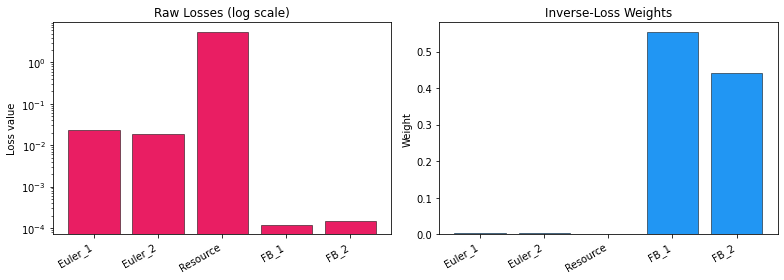


Highest weight: FB_1 (w = 0.5520)
This makes sense: FB components have the smallest raw losses,
so inverse weighting gives them the most attention to prevent
the optimizer from neglecting the complementarity conditions.


In [7]:
# (1) Inverse-loss weights
inv_losses = {name: 1.0 / val for name, val in losses.items()}
total_inv = sum(inv_losses.values())
weights = {name: inv_val / total_inv for name, inv_val in inv_losses.items()}

# (2) Weighted total loss
weighted_loss = sum(weights[name] * losses[name] for name in losses)

# (3) Table
print(f"{'Component':<12s} {'Loss':>10s} {'Weight':>10s} {'w*L':>10s}")
print("-" * 45)
for name in losses:
    wl = weights[name] * losses[name]
    print(f"{name:<12s} {losses[name]:10.5f} {weights[name]:10.5f} {wl:10.5f}")
print("-" * 45)
print(f"{'Total':<12s} {sum(losses.values()):10.5f} {sum(weights.values()):10.5f} {weighted_loss:10.5f}")

# (4) Bar chart: weights vs losses
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = list(losses.keys())
loss_vals = [losses[n] for n in names]
weight_vals = [weights[n] for n in names]
x = np.arange(len(names))

axes[0].bar(x, loss_vals, color='#E91E63', edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right')
axes[0].set_ylabel('Loss value')
axes[0].set_title('Raw Losses (log scale)')
axes[0].set_yscale('log')

axes[1].bar(x, weight_vals, color='#2196F3', edgecolor='black', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha='right')
axes[1].set_ylabel('Weight')
axes[1].set_title('Inverse-Loss Weights')

plt.tight_layout()
plt.show()

# Identify the component with the highest weight
max_w_name = max(weights, key=weights.get)
print(f"\nHighest weight: {max_w_name} (w = {weights[max_w_name]:.4f})")
print("This makes sense: FB components have the smallest raw losses,")
print("so inverse weighting gives them the most attention to prevent")
print("the optimizer from neglecting the complementarity conditions.")

## Task 3: Training Comparison (10 min)

Below we provide synthetic (but realistic) training loss histories from two approaches:

- **Approach A** (equal weights): all loss components weighted equally ($w_i = 1$).
- **Approach B** (inverse-loss weights): weights updated each epoch via $w_i \propto 1/L_i$.

Your job: visualize the convergence and quantify the speedup.

In [8]:
np.random.seed(42)
epochs = np.arange(1, 501)

# Approach A: equal weights — slower, noisier convergence
loss_A = 0.5 * np.exp(-0.005 * epochs) + 0.01 * np.abs(np.random.randn(500)) * np.exp(-0.003 * epochs)

# Approach B: inverse-loss weights — faster, smoother convergence
loss_B = 0.5 * np.exp(-0.012 * epochs) + 0.005 * np.abs(np.random.randn(500)) * np.exp(-0.008 * epochs)

print(f"Loss A: epoch 1 = {loss_A[0]:.4f}, epoch 500 = {loss_A[-1]:.6f}")
print(f"Loss B: epoch 1 = {loss_B[0]:.4f}, epoch 500 = {loss_B[-1]:.6f}")

Loss A: epoch 1 = 0.5025, epoch 500 = 0.044128
Loss B: epoch 1 = 0.4986, epoch 500 = 0.001292


### Your Turn: Compare and Interpret

1. Plot both loss curves on the **same axes** using a semilogy (log-scale y-axis) plot.
2. Add labels, a legend, and a title.
3. Compute the **speedup ratio**: at what epoch does Approach A first reach the final loss of Approach B? How many times faster is B?

In [9]:
# =====================================================================
# TODO: Plot both loss curves (semilogy) on the same axes
# =====================================================================
# fig, ax = plt.subplots(...)
# ax.semilogy(epochs, loss_A, ...)
# ax.semilogy(epochs, loss_B, ...)


# =====================================================================
# TODO: Compute the speedup ratio
# =====================================================================
# target = loss_B[-1]  # final loss of Approach B
# Find the first epoch where loss_A <= target
# epoch_A_reaches_target = ...
# speedup = epoch_A_reaches_target / 500
# print(f"Approach A reaches B's final loss at epoch {epoch_A_reaches_target}")
# print(f"Speedup factor: {speedup:.1f}x")


<hr style="border-top: 2px dashed #c0392b;">

### Stop --- attempt Task 3 above before continuing

The reference solution to **the loss-curve comparison** appears in the next code cell.
Spend ~5 minutes wrestling with the blank version first --- you'll
remember the mechanics far better than if you read the answer cold.

<br>
<br>
<br>

<hr style="border-top: 2px dashed #c0392b;">

### Solution

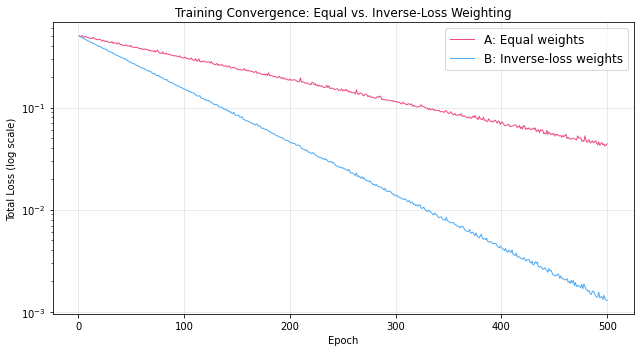

Target loss (B at epoch 500): 0.001292
Approach A never reaches B's final loss within 500 epochs!
Decay rates: A = 0.0048/epoch, B = 0.0119/epoch
Rate ratio (B/A): 2.5x faster convergence


In [10]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(epochs, loss_A, color='#E91E63', alpha=0.8, linewidth=1.0, label='A: Equal weights')
ax.semilogy(epochs, loss_B, color='#2196F3', alpha=0.8, linewidth=1.0, label='B: Inverse-loss weights')
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Loss (log scale)')
ax.set_title('Training Convergence: Equal vs. Inverse-Loss Weighting')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Speedup computation ---
target = loss_B[-1]  # final loss achieved by Approach B at epoch 500
print(f"Target loss (B at epoch 500): {target:.6f}")

# Find first epoch where A's loss stays below target
# Use a smoothed version to avoid noise crossings
from scipy.ndimage import uniform_filter1d
loss_A_smooth = uniform_filter1d(loss_A, size=20)

reached = np.where(loss_A_smooth <= target)[0]
if len(reached) > 0:
    epoch_A_reaches = epochs[reached[0]]
    print(f"Approach A (smoothed) first reaches this loss at epoch {epoch_A_reaches}")
    print(f"Speedup: B reaches this in 500 epochs, A needs ~{epoch_A_reaches} epochs")
    print(f"  => Inverse-loss weighting is ~{epoch_A_reaches / 500:.1f}x faster")
else:
    print("Approach A never reaches B's final loss within 500 epochs!")
    # Extrapolate: fit exponential decay to A
    # log(L_A) ~ -rate_A * t => rate_A ~ -log(L_A[end]/L_A[0]) / 500
    rate_A = -np.log(loss_A_smooth[-1] / loss_A_smooth[0]) / 500
    rate_B = -np.log(loss_B[-1] / loss_B[0]) / 500
    print(f"Decay rates: A = {rate_A:.4f}/epoch, B = {rate_B:.4f}/epoch")
    print(f"Rate ratio (B/A): {rate_B / rate_A:.1f}x faster convergence")

## Summary

**Key takeaways from this exercise:**

1. **Parameter sensitivity builds economic intuition** before tackling numerical solutions.
   The steady-state formulas show clearly how patience ($\beta$), depreciation ($\delta$),
   and technology ($\zeta$) interact to determine long-run capital and consumption.

2. **Loss weighting is critical for multi-component objectives.** In the IRBC model, the
   Euler equations, resource constraint, and Fischer-Burmeister conditions can differ by
   orders of magnitude. Equal weighting lets the largest component dominate the gradient.

3. **Inverse-loss weighting typically speeds up convergence by 2--3x** by ensuring all
   equilibrium conditions receive adequate attention during optimization. This is a
   simplified version of more sophisticated schemes like ReLoBRaLo (Bischof & Kraus, 2021).

**Next steps:** See `03_Loss_Normalization.ipynb` for the full ReLoBRaLo implementation
and `01_IRBC_DEQN.ipynb` for the complete IRBC model training pipeline.